# Random Forest Classifier Model
- Entire VIF normalized dataset model

### Import all the necessary libraries and frameworks

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import shap, joblib, os

### Data path to different folders
 - dataset input
 - model output (saved models)
 - evaluation metrics
 - SHAP value exports
### These are used to store outputs like trained models, feature importances, and SHAP values.


In [42]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
importance_dir = "../data/feature_importance/per_country"
model_dir = "../models/per_country"
metrics_dir = "../data/evaluation_metrics/per_country"
IMPORTANCE_DIR = "../data/feature_importance"
SHAP_DIR = "../data/shap_values"


os.makedirs(importance_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

### Initial setup

In [43]:
drop_cols = ['date', 'Country']
targets = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
random_state = 42

### Load data

-  Load the VIF-normalized panel dataset from Excel
- Convert the 'date' column to datetime format so we can sort/filter by time later
-  Sorting by 'Country' and 'date' ensures time-series order is preserved within each country

In [44]:
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Country', 'date'])

### Evaluation Results container
- Placeholder list to store model performance metrics (AUC, F1, etc.) for each country
- This gets appended inside the loop and later converted into a DataFrame for export


In [45]:
all_results = []

### Target variable
- Define the target variable to predict — here it's 'RECESS_OVER'
- This flag marks the end of a recession. The model will try to learn patterns leading to recovery.
- It can be changed to 'RECESS' or 'RECESS_PERIOD' to switch tasks


In [88]:
target = "RECESS_OVER"

### Split the data
- We are using the 50% of the data for training, 30% for validation and 20% for testing

### Define feature matrix X by dropping unnecessary or target columns
- drop_cols: 'date' and 'Country' (handled separately)
- RECESS targets: excluded to avoid data leakage during prediction of a specific target
- Define y as the binary classification target (e.g., 'RECESS_OVER')


In [89]:
X = df.drop(columns=drop_cols + ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD'])
y = df[target]

### Define temporal windows for time-based train/validation/test split
- Train: 1995–2009, Val: 2010–2018, Test: 2019–May 2024
- Important: this strategy mimics a real-world forecasting scenario where future data is unseen

In [90]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2024-05-31"

### Build boolean masks to slice the DataFrame into train/val/test splits
- These masks ensure we preserve the temporal integrity of the data
- They will be used to subset X and y in the next step


In [91]:
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

### Apply the boolean masks to split the features (X) and labels (y) into:
- training set (1995–2009)
- validation set (2010–2018)
- test set (2019–May 2024)

In [92]:
X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

### Quick sanity check to verify sample sizes and date ranges of each split
- Helps confirm that data was split correctly and no overlap occurred

In [93]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")

Train: 1080 samples
Validation: 648 samples
Test: 390 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Building the model

# Initialize the Random Forest Classifier:
- n_estimators=100: build 100 decision trees
- class_weight='balanced': handle class imbalance by giving more weight to the minority class (recessions)
- random_state: ensure reproducibility

### Fit the model on the training set.
- This is the baseline model — hyperparameters may be adjusted in future versions


In [94]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=random_state
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Threshold tuning on the validation set

### Generate predicted probabilities for the validation set
- Search for the best classification threshold (between 0.1 and 0.9)
- This loop picks the threshold that gives the highest F1 score on validation
- This tuning is critical for imbalanced datasets (default threshold 0.5 often underperforms)


In [95]:
y_val_prob = model.predict_proba(X_val)[:, 1]
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

### Prediction
-  Predict probabilities for the test set
-  Apply the threshold that was tuned on validation to generate final binary predictions
-  This ensures that model is evaluated using the most balanced decision point for F1 score


In [96]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > best_thresh).astype(int)

### Model Performance
#### Calculate key evaluation metrics for the test set:
- AUC: how well the model ranks positives over negatives
- F1: harmonic mean of precision and recall (important when data is imbalanced)
- Precision: how many predicted recessions were correct
- Recall: how many actual recessions we caught
- Accuracy: overall correctness (less informative for imbalanced sets)

In [97]:
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [98]:
print("Threshold Tuning")
print(f"   Optimal Threshold: {best_thresh:.2f}\n")

print("Evaluation Metrics")
print(f"   AUC       : {auc:.3f}")
print(f"   F1 Score  : {f1:.3f}")
print(f"   Precision : {precision:.3f}")
print(f"   Recall    : {recall:.3f}")
print(f"   Accuracy  : {accuracy:.3f}")


Threshold Tuning
   Optimal Threshold: 0.23

Evaluation Metrics
   AUC       : 0.540
   F1 Score  : 0.125
   Precision : 0.084
   Recall    : 0.241
   Accuracy  : 0.749


### Save the model
- Save the trained Random Forest model as a .pkl file for reuse or inspection
- File is named with the target (e.g., RECESS_OVER) to keep everything organized
- It can reload it later with joblib.load()

In [99]:
joblib.dump(model, f"{model_dir}/RFC_model_{target}_VIF_full.pkl")

['../models/per_country/RFC_model_RECESS_OVER_VIF_full.pkl']

### Feature Importance
- Compute feature importance from the trained Random Forest model
- Save the results to a CSV file for documentation or use in SHAP comparisons later


In [100]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importance_path = os.path.join(IMPORTANCE_DIR, f"RCF_{target}_importance.csv")
importances.to_csv(importance_path)

print(importances)
print(f"[INFO] Feature importance saved: {importance_path}")

[INFO] Feature importance saved: ../data/feature_importance\XGB_RECESS_OVER_importance.csv


### SHAP
- Use SHAP's TreeExplainer to explain the trained Random Forest model
- This will compute SHAP values for each feature in the training set

In [101]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

- Focus only on SHAP values for class 1 (predicting recession)
- Create a DataFrame from the SHAP array
- Compute the mean absolute SHAP value for each feature — this gives global feature importance
- These are used to rank which features contributed most overall to the model’s predictions


In [102]:
shap_array = shap_values.values[:, :, 1]  # shape: (n_samples, n_features)

shap_df = pd.DataFrame(shap_array, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

### Save the mean SHAP values to a CSV for future visualization or comparison


In [103]:
shap_path = os.path.join(SHAP_DIR, f"RCF_SHAP_{target}.csv")
mean_shap.to_csv(shap_path)

print(f"[INFO] SHAP values saved: {shap_path}")

[INFO] SHAP values saved: ../data/shap_values\XGB_SHAP_RECESS_OVER.csv


### Plot of SHAP values that influence recession
- Plot a SHAP bar plot for the top 20 features contributing to predictions
- This helps interpret which macroeconomic variables the model relied on most


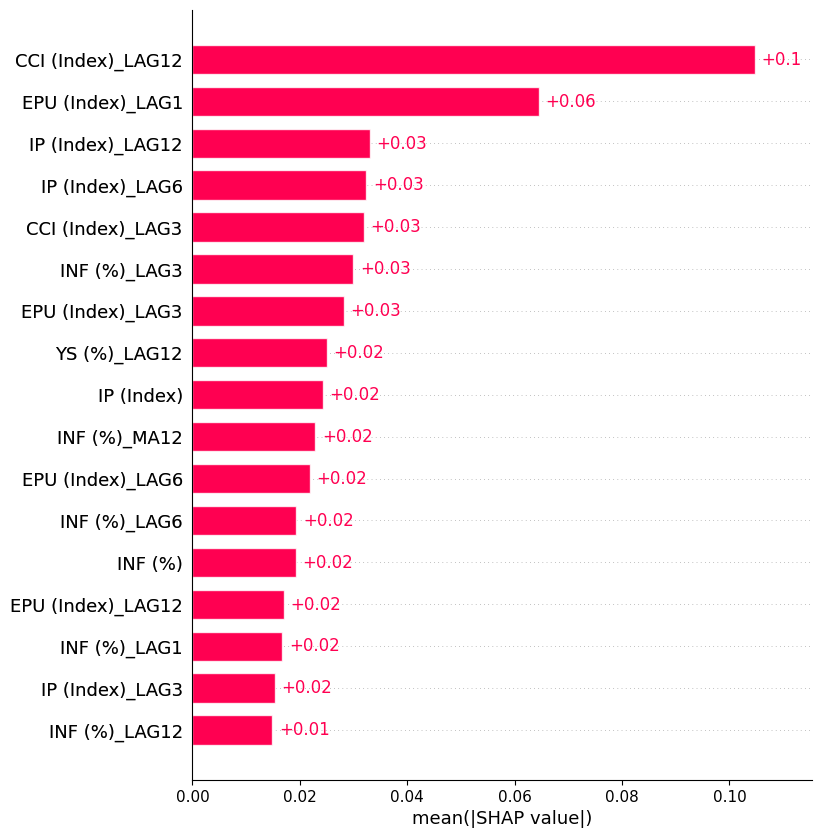

In [104]:
shap_values_class1 = shap_values.values[:, :, 1]

# Create a summary bar plot with top 20 features
shap.plots.bar(
    shap.Explanation(values=shap_values_class1,
                     base_values=shap_values.base_values[:, 1],
                     data=X_train.values,
                     feature_names=X_train.columns),
    max_display=20,
    show=True
)

### Store the prediction values on a file
- Save the test set predictions, probabilities, and ground truth labels
- Useful for post-hoc error analysis — e.g., checking false positives/negatives
- File is stored by target (RECESS, RECESS_OVER, etc.)

In [105]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})
pred_df.to_csv(f"{metrics_dir}/RFC_predictions_{target}_VIF_full.csv", index=False)

- Append this model's evaluation metrics to the results list
- Create a DataFrame for exporting or summarizing across multiple targets

In [106]:
all_results.append({
    "Target": target,
    "AUC": auc,
    "F1": best_f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh
})

results_df = pd.DataFrame(all_results)

### Save the performance on a file
- Save the cumulative results DataFrame to disk
- Finally, display the DataFrame to visually confirm all metrics and thresholds


In [108]:
results_df.to_csv(f"{metrics_dir}/RFC_evaluation_{target}_VIF_full.csv", index=False)
results_df

,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,RECESS,0.625766,0.630872,0.281768,1.000000,0.333333,0.30
1,RECESS_PERIOD,0.515490,0.138756,0.267267,0.946809,0.361538,0.12
2,RECESS_OVER,0.540453,0.068376,0.084337,0.241379,0.748718,0.23
